# Stage 07 Homework — Outliers, Risk, and Assumptions

This submission adapts the canonical starter into a reproducible analysis
with validated IQR/Z-score functions, visual diagnostics, and sensitivity
results for untreated, filtered, and winsorized data.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name != "homework07":
    raise RuntimeError("Run this notebook from homework/homework07")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
raw_dir = ROOT / "data" / "raw"
processed_dir = ROOT / "data" / "processed"
raw_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)
np.random.seed(17)

## Generate and reload the starter dataset

In [2]:
dates = pd.date_range("2022-01-03", "2022-06-10", freq="B")
returns = np.random.normal(0, 0.01, len(dates))
returns[dates < "2022-05-01"] -= 0.0015
shocks = {
    "2022-05-02": 0.1748425237194541,
    "2022-05-03": -0.16825801732486943,
    "2022-05-06": -0.19667220757153227,
    "2022-05-09": 0.21240223590614747,
    "2022-05-12": -0.178729287231294,
}
for date, value in shocks.items():
    returns[np.where(dates == pd.Timestamp(date))[0][0]] = value
return_2 = 0.6 * returns + np.random.normal(0, 0.005, len(dates))
generated = pd.DataFrame({
    "date": dates,
    "daily_return": returns,
    "daily_return_2": return_2,
})
raw_path = raw_dir / "outliers_homework.csv"
generated.to_csv(raw_path, index=False)
df = pd.read_csv(raw_path, parse_dates=["date"])
print(raw_path.relative_to(ROOT), df.shape)
df.head()

data/raw/outliers_homework.csv (115, 3)


,date,daily_return,daily_return_2
0,2022-01-03,0.001263,0.003834
1,2022-01-04,-0.020046,-0.009506
2,2022-01-05,0.004739,-0.000535
3,2022-01-06,0.009953,0.012539
4,2022-01-07,0.008872,0.009840


## Detect and flag extremes

In [3]:
from src.outliers import (
    detect_outliers_iqr,
    detect_outliers_zscore,
    sensitivity_summary,
    winsorize_series,
)

df["outlier_iqr"] = detect_outliers_iqr(df["daily_return"], k=1.5)
df["outlier_z"] = detect_outliers_zscore(df["daily_return"], threshold=3.0)
print(df[["outlier_iqr", "outlier_z"]].sum())
df.loc[df[["outlier_iqr", "outlier_z"]].any(axis=1)]

outlier_iqr    9
outlier_z      5
dtype: int64


,date,daily_return,daily_return_2,outlier_iqr,outlier_z
41,2022-03-01,0.031952,0.023944,True,False
63,2022-03-31,-0.031101,-0.020710,True,False
85,2022-05-02,0.174843,0.112930,True,True
86,2022-05-03,-0.168258,-0.095461,True,True
87,2022-05-04,-0.033999,-0.028415,True,False
89,2022-05-06,-0.196672,-0.115209,True,True
90,2022-05-09,0.212402,0.136536,True,True
92,2022-05-11,0.028711,0.017664,True,False
93,2022-05-12,-0.178729,-0.100548,True,True


## Visual checks

/var/folders/dw/c8s1528153ncqpv4jf_p2j6m0000gn/T/ipykernel_72772/1800328546.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(df["daily_return"], vert=True)


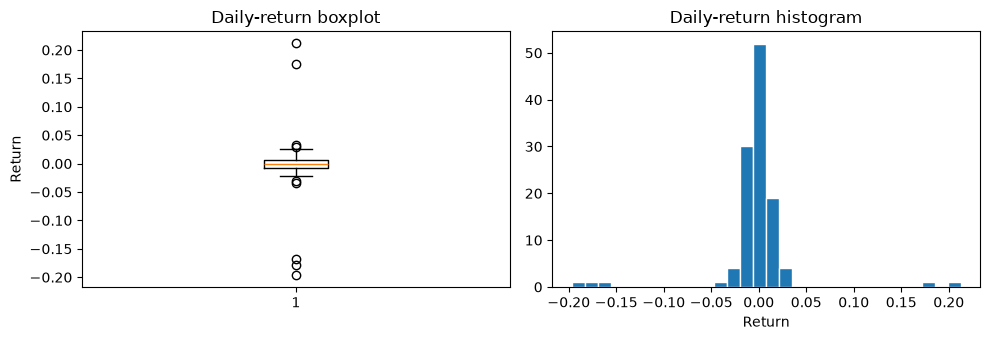

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].boxplot(df["daily_return"], vert=True)
axes[0].set_title("Daily-return boxplot")
axes[0].set_ylabel("Return")
axes[1].hist(df["daily_return"], bins=30, edgecolor="white")
axes[1].set_title("Daily-return histogram")
axes[1].set_xlabel("Return")
fig.tight_layout()
plot_path = processed_dir / "outlier_visual_checks.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()

## Distribution sensitivity

In [5]:
summary = sensitivity_summary(
    df["daily_return"], df["outlier_iqr"], lower=0.05, upper=0.95
)
summary_path = processed_dir / "outlier_sensitivity_summary.csv"
summary.to_csv(summary_path)
summary

,count,mean,median,std
all,115,-0.001434,-0.000187,0.040579
filtered_iqr,106,-0.000039,-0.000100,0.009443
winsorized,115,-0.000251,-0.000187,0.010623


## Regression sensitivity

In [6]:
def regression_metrics(x, y):
    slope, intercept = np.polyfit(x, y, deg=1)
    predicted = slope * x + intercept
    residual = y - predicted
    ss_res = np.square(residual).sum()
    ss_tot = np.square(y - y.mean()).sum()
    return {
        "count": len(x),
        "slope": slope,
        "intercept": intercept,
        "r2": 1 - ss_res / ss_tot,
        "mae": np.abs(residual).mean(),
    }

keep = ~df["outlier_iqr"]
winsorized_x = winsorize_series(df["daily_return"], 0.05, 0.95)
regression = pd.DataFrame.from_dict({
    "all": regression_metrics(df["daily_return"], df["daily_return_2"]),
    "filtered_iqr": regression_metrics(
        df.loc[keep, "daily_return"], df.loc[keep, "daily_return_2"]
    ),
    "winsorized_x": regression_metrics(winsorized_x, df["daily_return_2"]),
}, orient="index")
regression.to_csv(processed_dir / "regression_sensitivity.csv")
regression

,count,slope,intercept,r2,mae
all,115,0.605869,0.000201,0.961859,0.003951
filtered_iqr,106,0.589679,-0.000049,0.573566,0.003851
winsorized_x,115,1.467237,-0.000300,0.386601,0.010746


## Reflection

I used a 1.5×IQR rule because it is distribution-light and a population
Z-score threshold of 3.0 because the starter data were generated from an
approximately normal center. Both functions reject invalid parameters,
preserve indexes, and leave missing values unflagged. I compared the raw
sample with IQR filtering and 5th/95th-percentile winsorization rather than
declaring one treatment correct.

The injected shocks dominate the untreated standard deviation and strongly
influence the regression relationship because the second return series was
constructed from the first. Filtering makes the central observations look
calmer; winsorization keeps the dates but caps their leverage. Neither result
proves that treatment improves the model. In financial data, an extreme can
be a genuine market event and the main evidence about tail risk. Removing it
could understate risk, distort stress behavior, and make historical fit look
deceptively stable. I would preserve the raw series, report sensitivity, and
choose a treatment only after tying it to the downstream decision.

In [7]:
assert len(df) == 115 and df["date"].is_unique
assert df["outlier_iqr"].dtype == bool and df["outlier_z"].dtype == bool
assert df["outlier_iqr"].sum() >= len(shocks)
assert set(summary.index) == {"all", "filtered_iqr", "winsorized"}
assert summary_path.is_file() and plot_path.is_file()
print("All Stage 07 homework checks passed.")

All Stage 07 homework checks passed.
